In [3]:
import pandas  as pd
import numpy as np

In [12]:
pd.__version__

'3.0.3'

In [4]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [5]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [6]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [7]:
df.head().T

,0,1,2,3,4
engine_displacement,170,130,170,220,210
num_cylinders,3.0,5.0,NaN,4.0,1.0
horsepower,159.0,97.0,78.0,NaN,140.0
vehicle_weight,3413.433759,3149.664934,3079.038997,2542.392402,3460.87099
acceleration,17.7,17.8,15.1,20.2,14.4
model_year,2003,2007,2018,2009,2009
origin,Europe,USA,Europe,USA,Europe
fuel_type,Gasoline,Gasoline,Gasoline,Diesel,Gasoline
drivetrain,All-wheel drive,Front-wheel drive,Front-wheel drive,All-wheel drive,All-wheel drive
num_doors,0.0,0.0,0.0,2.0,2.0


In [8]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64


In [9]:
df.count()

engine_displacement    9704
num_cylinders          9222
horsepower             8996
vehicle_weight         9704
acceleration           8774
model_year             9704
origin                 9704
fuel_type              9704
drivetrain             9704
num_doors              9202
fuel_efficiency_mpg    9704
dtype: int64

In [11]:
df

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369
...,...,...,...,...,...,...,...,...,...,...,...
9699,140,5.0,164.0,2981.107371,17.3,2013,Europe,Diesel,Front-wheel drive,NaN,15.101802
9700,180,NaN,154.0,2439.525729,15.0,2004,USA,Gasoline,All-wheel drive,0.0,17.962326
9701,220,2.0,138.0,2583.471318,15.1,2008,USA,Diesel,All-wheel drive,-1.0,17.186587
9702,230,4.0,177.0,2905.527390,19.4,2011,USA,Diesel,Front-wheel drive,1.0,15.331551


In [15]:
df.fuel_type.nunique()

2

In [16]:
df.fuel_type.unique()

<ArrowStringArray>
['Gasoline', 'Diesel']
Length: 2, dtype: str

In [21]:
df[df['origin'] == 'Asia'].loc[df[df['origin'] == 'Asia']['fuel_efficiency_mpg'].idxmax()]

engine_displacement                  330
num_cylinders                        3.0
horsepower                         136.0
vehicle_weight               1223.298226
acceleration                         NaN
model_year                          2001
origin                              Asia
fuel_type                       Gasoline
drivetrain             Front-wheel drive
num_doors                            1.0
fuel_efficiency_mpg            23.759123
Name: 9387, dtype: object

In [22]:
df['horsepower'].median() # 中位数

np.float64(149.0)

In [25]:
df['horsepower'].mode()[0] # 常见值

np.float64(152.0)

In [26]:
df['horsepower'].describe()

count    8996.000000
mean      149.657292
std        29.879555
min        37.000000
25%       130.000000
50%       149.000000
75%       170.000000
max       271.000000
Name: horsepower, dtype: float64

In [27]:
df.horsepower.isnull().sum()

np.int64(708)

In [28]:
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mode()[0]) # 常见值填充空值

In [29]:
df.horsepower.isnull().sum()

np.int64(0)

In [31]:
df['horsepower'].median() # 中位数   #发现中位数增加了

np.float64(152.0)

In [37]:
asia_cars = df[df['origin'] == 'Asia']
asia_cars

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
8,250,1.0,174.0,2714.219310,10.3,2016,Asia,Diesel,Front-wheel drive,-1.0,16.823554
12,320,5.0,145.0,2783.868974,15.1,2010,Asia,Diesel,All-wheel drive,1.0,16.175820
14,200,6.0,160.0,3582.687368,14.9,2007,Asia,Diesel,All-wheel drive,0.0,11.871091
20,150,3.0,197.0,2231.808142,18.7,2011,Asia,Gasoline,Front-wheel drive,1.0,18.889083
21,160,4.0,133.0,2659.431451,NaN,2016,Asia,Gasoline,Front-wheel drive,-1.0,16.077730
...,...,...,...,...,...,...,...,...,...,...,...
9688,260,4.0,152.0,3948.404625,15.5,2018,Asia,Diesel,All-wheel drive,-1.0,11.054830
9692,180,3.0,188.0,3680.341381,18.0,2016,Asia,Gasoline,Front-wheel drive,1.0,11.711653
9693,280,2.0,148.0,2545.070139,15.6,2012,Asia,Diesel,All-wheel drive,0.0,17.202782
9698,180,1.0,131.0,3107.427820,13.2,2005,Asia,Gasoline,Front-wheel drive,-2.0,13.933716


In [38]:
asia_cars_subset = asia_cars[['vehicle_weight', 'model_year']]
asia_cars_subset

,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
...,...,...
9688,3948.404625,2018
9692,3680.341381,2016
9693,2545.070139,2012
9698,3107.427820,2005


In [39]:
first_7_rows = asia_cars_subset.head(7) 
first_7_rows

,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
34,2844.227534,2014
38,3761.994038,2019


In [40]:
X = first_7_rows.values
X

array([[2714.21930965, 2016.        ],
       [2783.86897424, 2010.        ],
       [3582.68736772, 2007.        ],
       [2231.8081416 , 2011.        ],
       [2659.43145076, 2016.        ],
       [2844.22753389, 2014.        ],
       [3761.99403819, 2019.        ]])

In [41]:
X_T = X.T
X_T

array([[2714.21930965, 2783.86897424, 3582.68736772, 2231.8081416 ,
        2659.43145076, 2844.22753389, 3761.99403819],
       [2016.        , 2010.        , 2007.        , 2011.        ,
        2016.        , 2014.        , 2019.        ]])

In [44]:
XTX = np.dot(X_T, X)
XTX

array([[62248334.33150762, 41431216.5073268 ],
       [41431216.5073268 , 28373339.        ]])

In [46]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 5.71497081e-07, -8.34509443e-07],
       [-8.34509443e-07,  1.25380877e-06]])

In [47]:
X_unit_matrix = np.dot(XTX_inv,XTX) 
X_unit_matrix

array([[ 1.00000000e+00,  2.13808046e-15],
       [-3.87615815e-15,  1.00000000e+00]])

In [48]:
y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])

In [50]:
w = XTX_inv.dot(X_T).dot(y)
w

array([0.01386421, 0.5049067 ])

In [51]:
w_sum = w.sum()


In [52]:
w_sum

np.float64(0.5187709081074016)

### Look at the variable. Does it have a long tail?fuel_efficiency_mpg

In [62]:
df.fuel_efficiency_mpg.max()

np.float64(25.96722204888372)

In [63]:
df.fuel_efficiency_mpg.min()

np.float64(6.200970533392815)

In [64]:
df.fuel_efficiency_mpg.mean()

np.float64(14.985243228208573)

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib  inline   


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

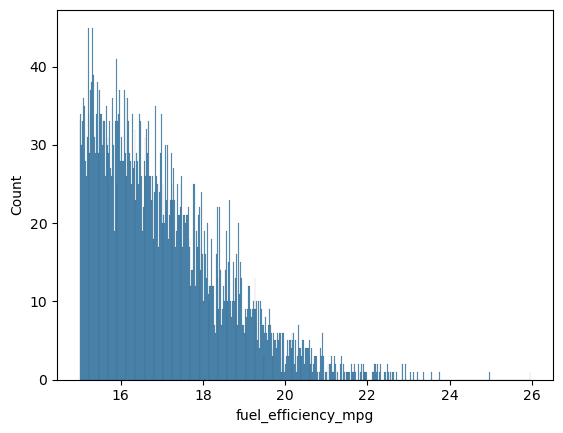

In [66]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg > 15 ],bins=500)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

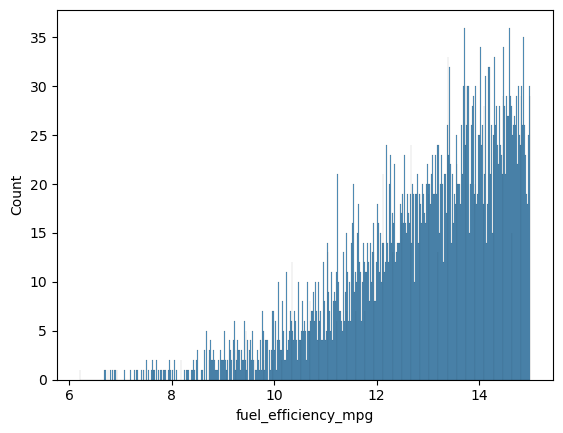

In [67]:
sns.histplot(df.fuel_efficiency_mpg[df.fuel_efficiency_mpg < 15 ],bins=500)

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

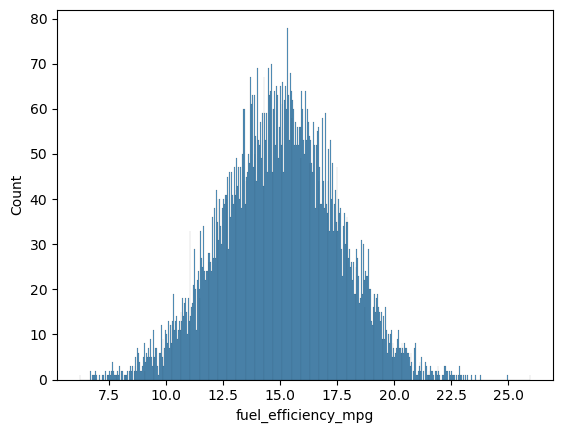

In [68]:
sns.histplot(df.fuel_efficiency_mpg,bins=500)

In [70]:
mpg_logs = np.log1p(df.fuel_efficiency_mpg) 

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

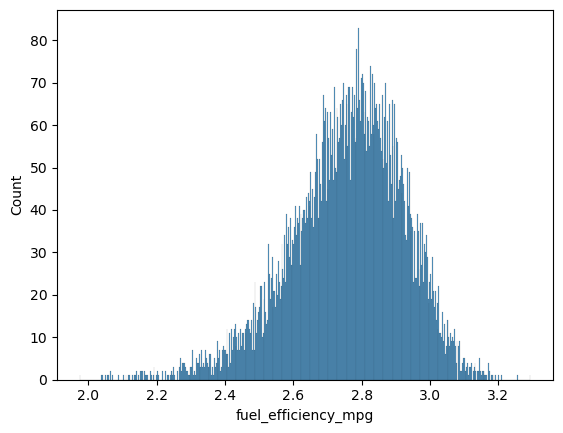

In [71]:
sns.histplot(mpg_logs,bins=500)

In [53]:
# 检查数据集中的所有空值情况
print("=" * 50)  
print("快速检查:")
print("=" * 50)
print(df.isnull().sum())

快速检查:
engine_displacement      0
num_cylinders          482
horsepower               0
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64


In [72]:
df.describe()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.000000,9222.000000,9704.000000,9704.000000,8774.000000,9704.000000,9202.000000,9704.000000
mean,199.708368,3.962481,149.828215,3001.280993,15.021928,2011.484027,-0.006412,14.985243
std,49.455319,1.999323,28.775248,497.894860,2.510339,6.659808,1.048162,2.556468
min,10.000000,0.000000,37.000000,952.681761,6.000000,2000.000000,-4.000000,6.200971
25%,170.000000,3.000000,131.000000,2666.248985,13.300000,2006.000000,-1.000000,13.267459
50%,200.000000,4.000000,152.000000,2993.226296,15.000000,2012.000000,0.000000,15.006037
75%,230.000000,5.000000,168.000000,3334.957039,16.700000,2017.000000,1.000000,16.707965
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222


In [73]:
df.shape[0]

9704

In [74]:
n = len(df)
n_val = int(n*0.2) 
n_test = int(n*0.2)
n_train = n - n_val - n_test 
n,n_val + n_test + n_train

(9704, 9704)

In [78]:
n_val,n_test,n_train

(1940, 1940, 5824)

In [81]:
idx = np.arange(n)
np.random.seed(42)
np.random.shuffle(idx) 
df.iloc[idx[:10]]

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209
4562,180,8.0,120.0,3551.398040,NaN,2013,Asia,Gasoline,All-wheel drive,0.0,12.145734
5885,210,3.0,118.0,3620.351977,NaN,2018,Europe,Diesel,Front-wheel drive,0.0,11.378399
3746,150,1.0,152.0,2524.407794,17.0,2012,Europe,Gasoline,All-wheel drive,1.0,16.667294
7109,160,4.0,151.0,2752.964230,19.0,2009,Europe,Gasoline,Front-wheel drive,0.0,15.819367
2698,250,5.0,147.0,3202.856567,12.6,2020,Asia,Gasoline,All-wheel drive,-1.0,14.100998


In [82]:
df_test = df.iloc[idx[n_val+n_train:]]  
df_val = df.iloc[idx[n_train:n_train + n_val]] 
df_train = df.iloc[idx[:n_train]]  
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209
...,...,...,...,...,...,...,...,...,...,...,...
1696,260,5.0,139.0,2606.972984,15.9,2009,USA,Gasoline,All-wheel drive,-1.0,16.964054
5685,280,4.0,132.0,4004.214323,12.8,2014,Europe,Diesel,Front-wheel drive,2.0,10.059094
6735,210,3.0,152.0,2500.175687,16.4,2020,Europe,Gasoline,Front-wheel drive,0.0,17.593237
2052,250,6.0,154.0,2254.313245,13.3,2002,Asia,Gasoline,Front-wheel drive,2.0,18.925748


In [83]:
# 进行索引重置，因为上面的df_train的结果中的索引，比较无序混乱
df_train = df_train.reset_index(drop=True)  #drop=True	不保留旧索引，直接丢弃，如果不丢弃，就得索引会成为1列数据
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_train

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
1,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
2,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
3,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
4,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209
...,...,...,...,...,...,...,...,...,...,...,...
5819,260,5.0,139.0,2606.972984,15.9,2009,USA,Gasoline,All-wheel drive,-1.0,16.964054
5820,280,4.0,132.0,4004.214323,12.8,2014,Europe,Diesel,Front-wheel drive,2.0,10.059094
5821,210,3.0,152.0,2500.175687,16.4,2020,Europe,Gasoline,Front-wheel drive,0.0,17.593237
5822,250,6.0,154.0,2254.313245,13.3,2002,Asia,Gasoline,Front-wheel drive,2.0,18.925748


In [84]:
y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)
y_train 

array([2.8703359 , 2.85061269, 2.97511223, ..., 2.92279789, 2.99201277,
       2.94261017], shape=(5824,))

In [85]:
del df_train['fuel_efficiency_mpg']

In [86]:
del df_val['fuel_efficiency_mpg']

In [87]:
del df_test['fuel_efficiency_mpg']

In [88]:
df_train.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors
0,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0
1,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0
2,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0
3,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0
4,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN


In [89]:
base = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

In [92]:
df[base].isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [ ]:
def prepare_X(df):
    df_num = df[base]  # 提取特征列数据
    df_num = df_num.fillna(0)  #对数据空值进行填充
    X= df_num.values  # 转换成numpy类型，
    return X

In [ ]:
def train_linear_regression(X,y):  
    ones = np.ones(X.shape[0])  
    X = np.column_stack([ones,X]) 
    XTX = X.T.dot(X) 
    XTX_inv = np.linalg.inv(XTX) 
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]



In [ ]:
train_linear_regression(X,y)